<a href="https://colab.research.google.com/github/Leila828/alzheimer_oasis_transfer_learning/blob/main/alzheimer_oasis_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Alzheimer's Prediction — OASIS (FIXED VERSION)

## What was wrong in v1:
| Bug | Effect |
|---|---|
| `rescale=1/255` applied to EfficientNet/ResNet | Corrupts input (they have built-in preprocessing) |
| Only 200 images/class → 140 train samples | Too few for any learning |
| `patience=4` on 10 epochs | Stops at epoch 4 before model converges |
| No class weights | Model collapses to majority class (NonDemented) |

## Fixes applied here:
- ✅ **Per-model preprocessing** — each backbone uses its own `preprocess_input`
- ✅ **500 images/class** (raises to ~1000 on Colab Pro)
- ✅ **Class weights** computed with sklearn
- ✅ **patience=8**, 20 epochs total
- ✅ **Mixed precision** (AMP) — 2× faster on T4
- ✅ **Label smoothing** in loss to prevent overconfidence

## 1 · Kaggle Setup

In [ ]:
!pip install -q kaggle
from google.colab import files
print('Upload kaggle.json:')
files.upload()

Upload kaggle.json:


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"habibleila","key":"eebdce50274f94dc9bad6bf856d5d702"}'}

In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
!kaggle datasets download -d ninadaithal/imagesoasis -p /content/oasis --unzip
!ls /content/oasis

Dataset URL: https://www.kaggle.com/datasets/ninadaithal/imagesoasis
License(s): apache-2.0
100% 1.23G/1.23G [00:13<00:00, 95.4MB/s]

Data


## 2 · Imports & Config

In [ ]:
import os, shutil, random, warnings, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import (
    VGG16, ResNet50, InceptionV3, MobileNetV2, EfficientNetB0
)
from tensorflow.keras.applications import (
    vgg16, resnet50, inception_v3, mobilenet_v2, efficientnet
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# Enable mixed precision (AMP) — 2× faster on T4/V100
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# ── GLOBAL CONFIG ────────────────────────────────────────────────────────
IMG_SIZE        = 224
BATCH_SIZE      = 32
EPOCHS          = 20          # Up from 10
FINE_TUNE_AFTER = 8           # Frozen epochs before fine-tuning
MAX_PER_CLASS   = 500         # Up from 200 — use 800 on Colab Pro
LEARNING_RATE   = 1e-4
DATA_ROOT       = '/content/oasis'
SUBSET_ROOT     = '/content/oasis_subset'
RESULTS         = {}
MODELS          = {}
HISTORIES       = {}

print('TF version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))
print('Mixed precision policy:', tf.keras.mixed_precision.global_policy().name)

TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: mixed_float16


## 3 · Dataset Exploration & Balanced Subset

In [ ]:
# ── Auto-detect class folders ──────────────────────────────────────────────
def find_class_dirs(root):
    root = Path(root)
    for p in sorted(root.rglob('*')):
        if p.is_dir():
            imgs = list(p.glob('*.jpg')) + list(p.glob('*.png')) + list(p.glob('*.jpeg'))
            if len(imgs) > 10:
                siblings = [s for s in p.parent.iterdir() if s.is_dir()]
                if len(siblings) >= 2:
                    return p.parent
    return root

CLASS_ROOT  = find_class_dirs(DATA_ROOT)
CLASSES     = sorted([d.name for d in CLASS_ROOT.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASSES)
print('Class root:', CLASS_ROOT)
print('Classes:', CLASSES)
print()

# Show full dataset sizes
for cls in CLASSES:
    n = len(list((CLASS_ROOT/cls).glob('*')))
    print(f'  {cls}: {n} images total')

Class root: /content/oasis/Data
Classes: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']

  Mild Dementia: 5002 images total
  Moderate Dementia: 488 images total
  Non Demented: 67222 images total
  Very mild Dementia: 13725 images total


In [ ]:
# ── Build balanced subset with stratified splits ───────────────────────────
def build_subset(class_root, subset_root, classes, max_per_class, split=(0.70, 0.15, 0.15)):
    subset_root = Path(subset_root)
    if subset_root.exists(): shutil.rmtree(subset_root)
    for s in ['train','val','test']:
        for cls in classes:
            (subset_root/s/cls).mkdir(parents=True, exist_ok=True)

    for cls in classes:
        imgs = (list((class_root/cls).glob('*.jpg')) +
                list((class_root/cls).glob('*.png')) +
                list((class_root/cls).glob('*.jpeg')))
        random.shuffle(imgs)
        imgs  = imgs[:max_per_class]
        n     = len(imgs)
        n_tr  = int(n * split[0])
        n_val = int(n * split[1])
        subs  = {'train': imgs[:n_tr], 'val': imgs[n_tr:n_tr+n_val], 'test': imgs[n_tr+n_val:]}
        for s, paths in subs.items():
            for p in paths: shutil.copy(p, subset_root/s/cls/p.name)
        print(f'  {cls}: train={len(subs["train"])}, val={len(subs["val"])}, test={len(subs["test"])}')

print(f'Building subset ({MAX_PER_CLASS}/class) …')
build_subset(CLASS_ROOT, SUBSET_ROOT, CLASSES, MAX_PER_CLASS)
print('Done.')

Building subset (500/class) …
  Mild Dementia: train=350, val=75, test=75
  Moderate Dementia: train=341, val=73, test=74
  Non Demented: train=350, val=75, test=75
  Very mild Dementia: train=350, val=75, test=75
Done.


train: {'Mild Dementia': 350, 'Moderate Dementia': 341, 'Non Demented': 350, 'Very mild Dementia': 350}
val: {'Mild Dementia': 75, 'Moderate Dementia': 73, 'Non Demented': 75, 'Very mild Dementia': 75}
test: {'Mild Dementia': 75, 'Moderate Dementia': 74, 'Non Demented': 75, 'Very mild Dementia': 75}


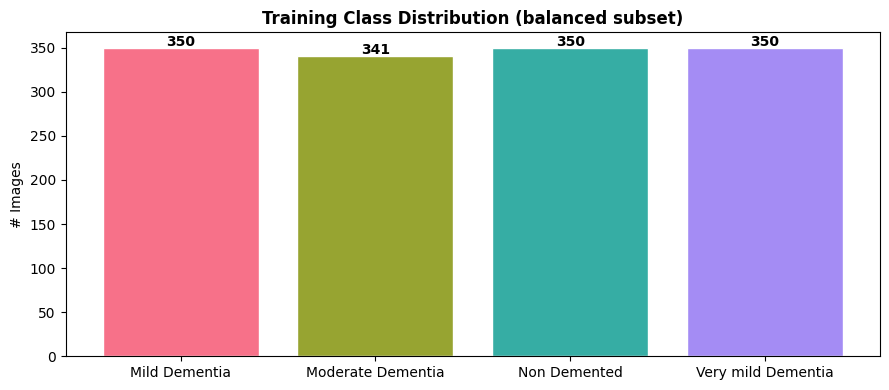

In [ ]:
# ── Class distribution bar chart ───────────────────────────────────────────
for split in ['train','val','test']:
    counts = {cls: len(list((Path(SUBSET_ROOT)/split/cls).glob('*'))) for cls in CLASSES}
    print(f'{split}: {counts}')

train_counts = {cls: len(list((Path(SUBSET_ROOT)/'train'/cls).glob('*'))) for cls in CLASSES}
plt.figure(figsize=(9, 4))
colors = sns.color_palette('husl', NUM_CLASSES)
bars = plt.bar(train_counts.keys(), train_counts.values(), color=colors, edgecolor='white')
for b, v in zip(bars, train_counts.values()):
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+2, str(v), ha='center', fontweight='bold')
plt.title('Training Class Distribution (balanced subset)', fontweight='bold')
plt.ylabel('# Images'); plt.tight_layout()
plt.savefig('/content/class_dist.png', dpi=100, bbox_inches='tight'); plt.show()

## 4 · KEY FIX: Per-Model Preprocessing

**This was the main bug.** `rescale=1/255` is only correct for VGG16.
- ResNet50 / InceptionV3 expect pixels in `[-1, 1]` via their own `preprocess_input`
- EfficientNetB0 / MobileNetV2 expect `[0, 255]` raw (they scale internally)

We fix this by NOT using `rescale` in ImageDataGenerator, and instead applying each model's `preprocess_input` function inside the pipeline.

In [ ]:
# Per-model preprocessing lookup
PREPROCESS_FN = {
    'VGG16'         : vgg16.preprocess_input,          # scales to ImageNet mean BGR
    'ResNet50'       : resnet50.preprocess_input,       # [-1, 1] range
    'InceptionV3'   : inception_v3.preprocess_input,   # [-1, 1] range
    'MobileNetV2'   : mobilenet_v2.preprocess_input,   # [-1, 1] range
    'EfficientNetB0': efficientnet.preprocess_input,   # [0,255] passthrough
}

def make_generators(arch_name, img_size=IMG_SIZE, batch_size=BATCH_SIZE):
    """Creates generators with the CORRECT preprocessing for each backbone."""
    preprocess_fn = PREPROCESS_FN[arch_name]

    # Train: augmentation applied BEFORE preprocessing
    train_aug = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        zoom_range=0.1,
        shear_range=0.05,
        fill_mode='nearest'
    )
    val_aug = ImageDataGenerator(preprocessing_function=preprocess_fn)

    train_gen = train_aug.flow_from_directory(
        f'{SUBSET_ROOT}/train', target_size=(img_size, img_size),
        batch_size=batch_size, class_mode='categorical', shuffle=True, seed=42
    )
    val_gen = val_aug.flow_from_directory(
        f'{SUBSET_ROOT}/val', target_size=(img_size, img_size),
        batch_size=batch_size, class_mode='categorical', shuffle=False
    )
    test_gen = val_aug.flow_from_directory(
        f'{SUBSET_ROOT}/test', target_size=(img_size, img_size),
        batch_size=batch_size, class_mode='categorical', shuffle=False
    )
    return train_gen, val_gen, test_gen

# ── Compute class weights to handle imbalance ──────────────────────────────
# (Even with balanced subset, this stabilises training)
def get_class_weights(train_gen):
    labels = train_gen.classes
    cw     = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
    return dict(enumerate(cw))

print('Per-model preprocessing configured.')

# Quick sanity check: verify pixel ranges per model
print('\nPreprocessing sanity check:')
test_img = np.random.randint(0, 255, (1, 224, 224, 3)).astype('float32')
for name, fn in PREPROCESS_FN.items():
    out = fn(test_img.copy())
    print(f'  {name:15s}: min={out.min():.1f}, max={out.max():.1f}')

Per-model preprocessing configured.

Preprocessing sanity check:
  VGG16          : min=-123.7, max=150.1
  ResNet50       : min=-123.7, max=150.1
  InceptionV3    : min=-1.0, max=1.0
  MobileNetV2    : min=-1.0, max=1.0
  EfficientNetB0 : min=0.0, max=254.0


## 5 · Model Builder

In [ ]:
def build_model(backbone_fn, name, img_size=IMG_SIZE, num_classes=NUM_CLASSES):
    input_shape = (img_size, img_size, 3)
    base = backbone_fn(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False

    inputs = keras.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    # Cast back to float32 for mixed precision compatibility
    x = layers.Dense(num_classes, dtype='float32')(x)
    outputs = layers.Activation('softmax', dtype='float32')(x)

    model = Model(inputs, outputs, name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(LEARNING_RATE),
        # Label smoothing prevents overconfident predictions
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    return model, base

ARCHITECTURES = {
    'VGG16'         : VGG16,
    'ResNet50'      : ResNet50,
    'InceptionV3'   : InceptionV3,
    'MobileNetV2'   : MobileNetV2,
    'EfficientNetB0': EfficientNetB0,
}
print('Architectures:', list(ARCHITECTURES.keys()))

Architectures: ['VGG16', 'ResNet50', 'InceptionV3', 'MobileNetV2', 'EfficientNetB0']


## 6 · Training Loop (Fixed)

In [ ]:
for arch_name, backbone_fn in ARCHITECTURES.items():
    print(f'\n{"="*60}')
    print(f'  Training: {arch_name}')
    print(f'{"="*60}')

    train_gen, val_gen, test_gen = make_generators(arch_name)
    class_weights = get_class_weights(train_gen)
    print(f'  Class weights: {class_weights}')

    model, base = build_model(backbone_fn, arch_name)

    callbacks = [
        EarlyStopping(
            monitor='val_accuracy',
            patience=8,                 # Was 4 — now gives model time to learn
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=3,
            verbose=1,
            min_lr=1e-8
        ),
        ModelCheckpoint(
            f'/content/{arch_name}_best.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=0
        )
    ]

    t0 = time.time()

    # ── Phase 1: Frozen base (head only) ────────────────────────────────
    print(f'  Phase 1: Training head ({FINE_TUNE_AFTER} epochs) …')
    h1 = model.fit(
        train_gen, validation_data=val_gen,
        epochs=FINE_TUNE_AFTER, callbacks=callbacks,
        class_weight=class_weights, verbose=1
    )

    # ── Phase 2: Fine-tune top layers ───────────────────────────────────
    print(f'  Phase 2: Fine-tuning top 30 layers …')
    base.trainable = True
    for layer in base.layers[:-30]:
        layer.trainable = False
    # Unfreeze BatchNorm layers — critical for EfficientNet / MobileNet
    for layer in base.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False  # Keep BN frozen to preserve statistics

    model.compile(
        optimizer=keras.optimizers.Adam(LEARNING_RATE / 10),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    h2 = model.fit(
        train_gen, validation_data=val_gen,
        epochs=EPOCHS - FINE_TUNE_AFTER, callbacks=callbacks,
        class_weight=class_weights, verbose=1
    )

    # Merge histories
    combined = {k: h1.history[k] + h2.history[k] for k in h1.history}
    t1 = time.time()

    test_gen.reset()
    loss, acc = model.evaluate(test_gen, verbose=0)

    HISTORIES[arch_name] = combined
    MODELS[arch_name]    = model
    RESULTS[arch_name]   = {
        'test_acc' : acc,
        'test_loss': loss,
        'time_min' : (t1-t0)/60,
        'params'   : model.count_params()
    }
    print(f'  ✅ Test Acc: {acc:.4f} | Loss: {loss:.4f} | Time: {(t1-t0)/60:.1f} min')

    # Free GPU memory between models
    keras.backend.clear_session()
    del model, base
    # Reload best checkpoint
    MODELS[arch_name] = keras.models.load_model(f'/content/{arch_name}_best.keras')
    print(f'  Best checkpoint reloaded.')


  Training: VGG16
Found 1391 images belonging to 4 classes.
Found 298 images belonging to 4 classes.
Found 299 images belonging to 4 classes.
  Class weights: {0: np.float64(0.9935714285714285), 1: np.float64(1.0197947214076246), 2: np.float64(0.9935714285714285), 3: np.float64(0.9935714285714285)}
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  Phase 1: Training head (8 epochs) …
Epoch 1/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 47s 699ms/step - accuracy: 0.2955 - loss: 1.6536 - val_accuracy: 0.3859 - val_loss: 1.3647 - learning_rate: 1.0000e-04
Epoch 2/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 18s 419ms/step - accuracy: 0.3630 - loss: 1.4599 - val_accuracy: 0.4664 - val_loss: 1.2356 - learning_rate: 1.0000e-04
Epoch 3/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 19s 423ms/step - accuracy: 0.3861 - loss: 1.3684 - val_accuracy: 0.5436 - val_loss: 1.1509 - learning_rate: 1.0000e-04
Epoch 4/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 18s 414ms/step - accuracy: 0.4508 - loss: 1.2725 - val_accuracy: 0.5537 - val_loss: 1.0993 - learning_rat

## 7 · Visualisations

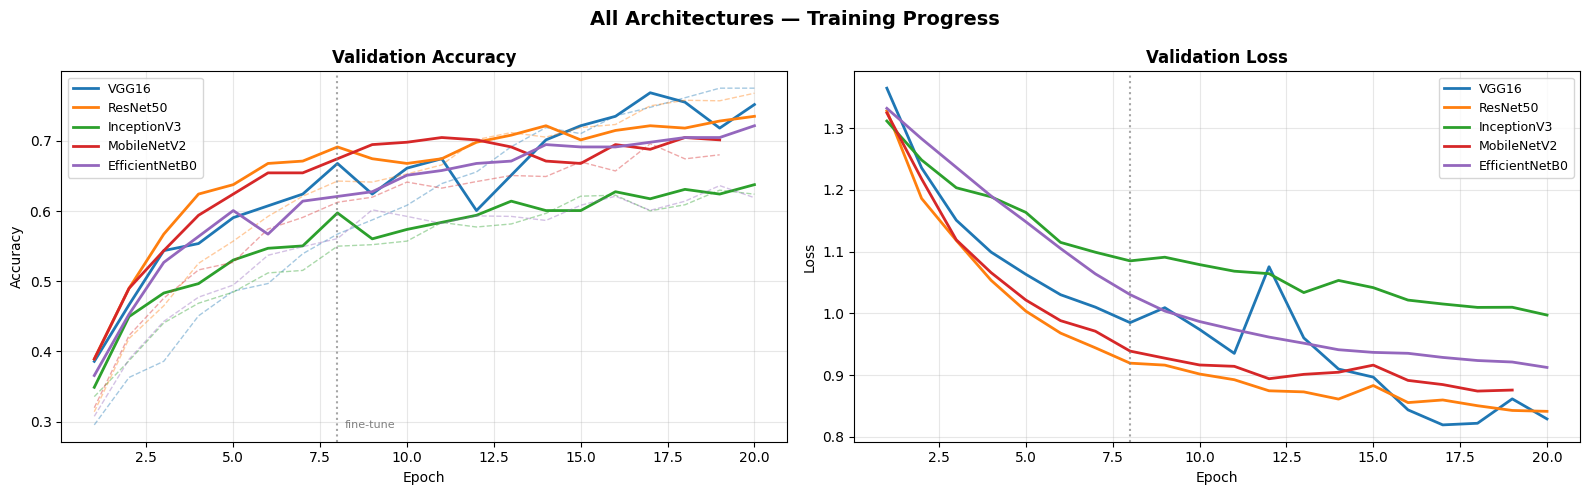

In [ ]:
palette = sns.color_palette('tab10', len(ARCHITECTURES))
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for (arch_name, hist), color in zip(HISTORIES.items(), palette):
    erange = range(1, len(hist['accuracy'])+1)
    axes[0].plot(erange, hist['val_accuracy'], label=arch_name, color=color, linewidth=2)
    axes[0].plot(erange, hist['accuracy'], color=color, linewidth=1, linestyle='--', alpha=0.4)
    axes[1].plot(erange, hist['val_loss'],     label=arch_name, color=color, linewidth=2)

for ax, title, ylabel in zip(axes, ['Validation Accuracy','Validation Loss'], ['Accuracy','Loss']):
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    ax.axvline(x=FINE_TUNE_AFTER, color='gray', linestyle=':', alpha=0.7)

axes[0].text(FINE_TUNE_AFTER+0.2, axes[0].get_ylim()[0]+0.02, 'fine-tune', fontsize=8, color='gray')
plt.suptitle('All Architectures — Training Progress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=120, bbox_inches='tight'); plt.show()

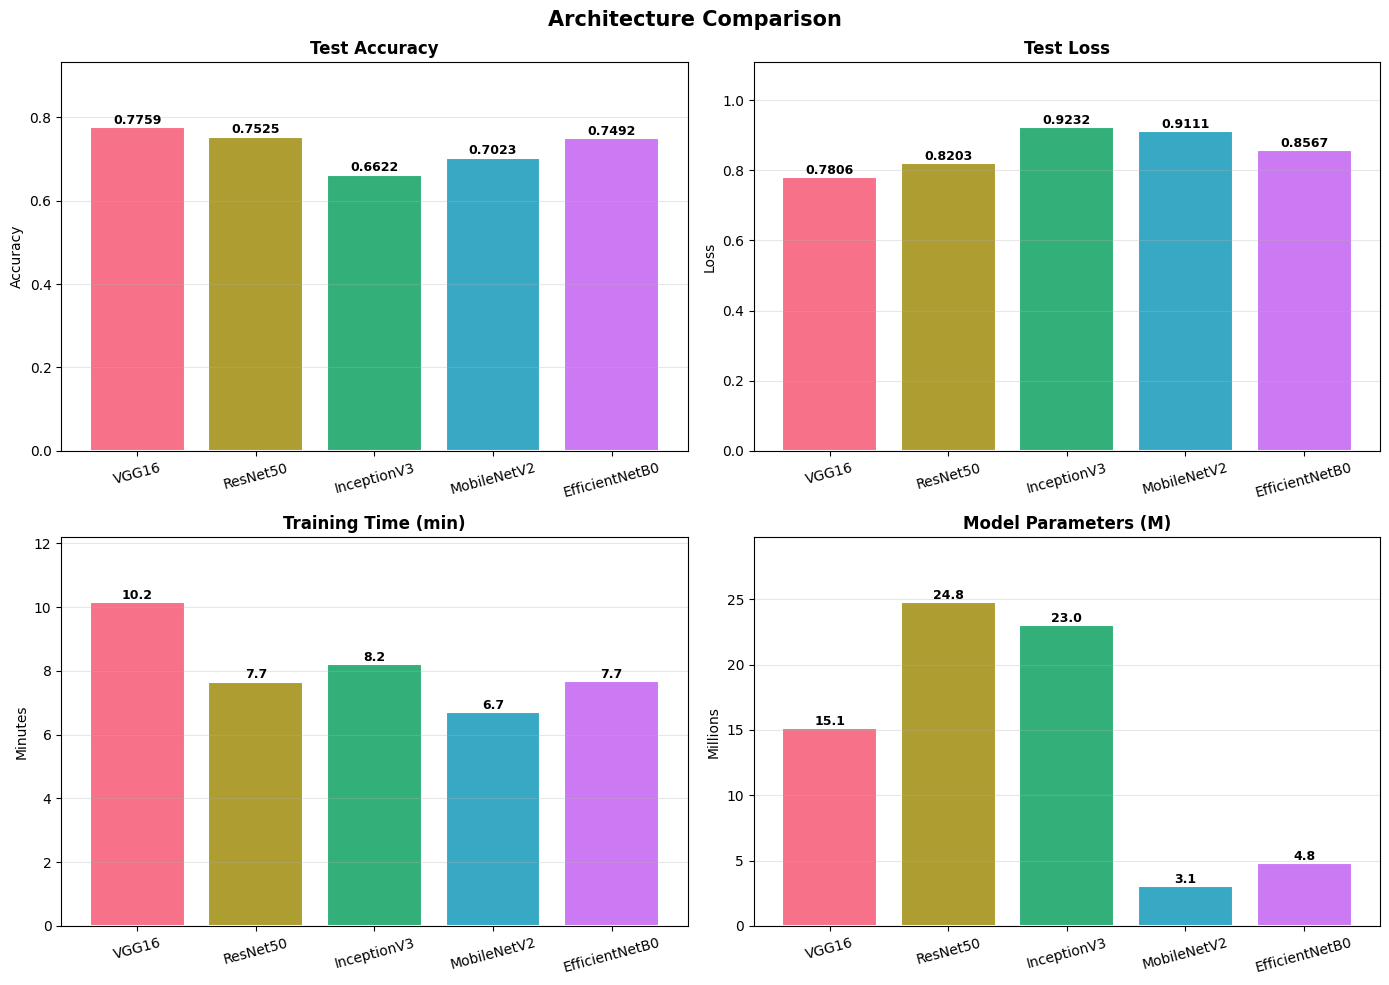

In [ ]:
import pandas as pd
names  = list(RESULTS.keys())
accs   = [RESULTS[n]['test_acc']   for n in names]
losses = [RESULTS[n]['test_loss']  for n in names]
times  = [RESULTS[n]['time_min']   for n in names]
params = [RESULTS[n]['params']/1e6 for n in names]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = sns.color_palette('husl', len(names))

def bar_plot(ax, values, title, ylabel, fmt='{:.4f}'):
    bars = ax.bar(names, values, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(values)*1.2)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                fmt.format(val), ha='center', va='bottom', fontweight='bold', fontsize=9)
    ax.tick_params(axis='x', rotation=15); ax.grid(axis='y', alpha=0.3)

bar_plot(axes[0,0], accs,   'Test Accuracy',        'Accuracy', '{:.4f}')
bar_plot(axes[0,1], losses, 'Test Loss',             'Loss',     '{:.4f}')
bar_plot(axes[1,0], times,  'Training Time (min)',   'Minutes',  '{:.1f}')
bar_plot(axes[1,1], params, 'Model Parameters (M)',  'Millions', '{:.1f}')
plt.suptitle('Architecture Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/model_comparison.png', dpi=120, bbox_inches='tight'); plt.show()

Found 1391 images belonging to 4 classes.
Found 298 images belonging to 4 classes.
Found 299 images belonging to 4 classes.
Found 1391 images belonging to 4 classes.
Found 298 images belonging to 4 classes.
Found 299 images belonging to 4 classes.
Found 1391 images belonging to 4 classes.
Found 298 images belonging to 4 classes.
Found 299 images belonging to 4 classes.
Found 1391 images belonging to 4 classes.
Found 298 images belonging to 4 classes.
Found 299 images belonging to 4 classes.
Found 1391 images belonging to 4 classes.
Found 298 images belonging to 4 classes.
Found 299 images belonging to 4 classes.


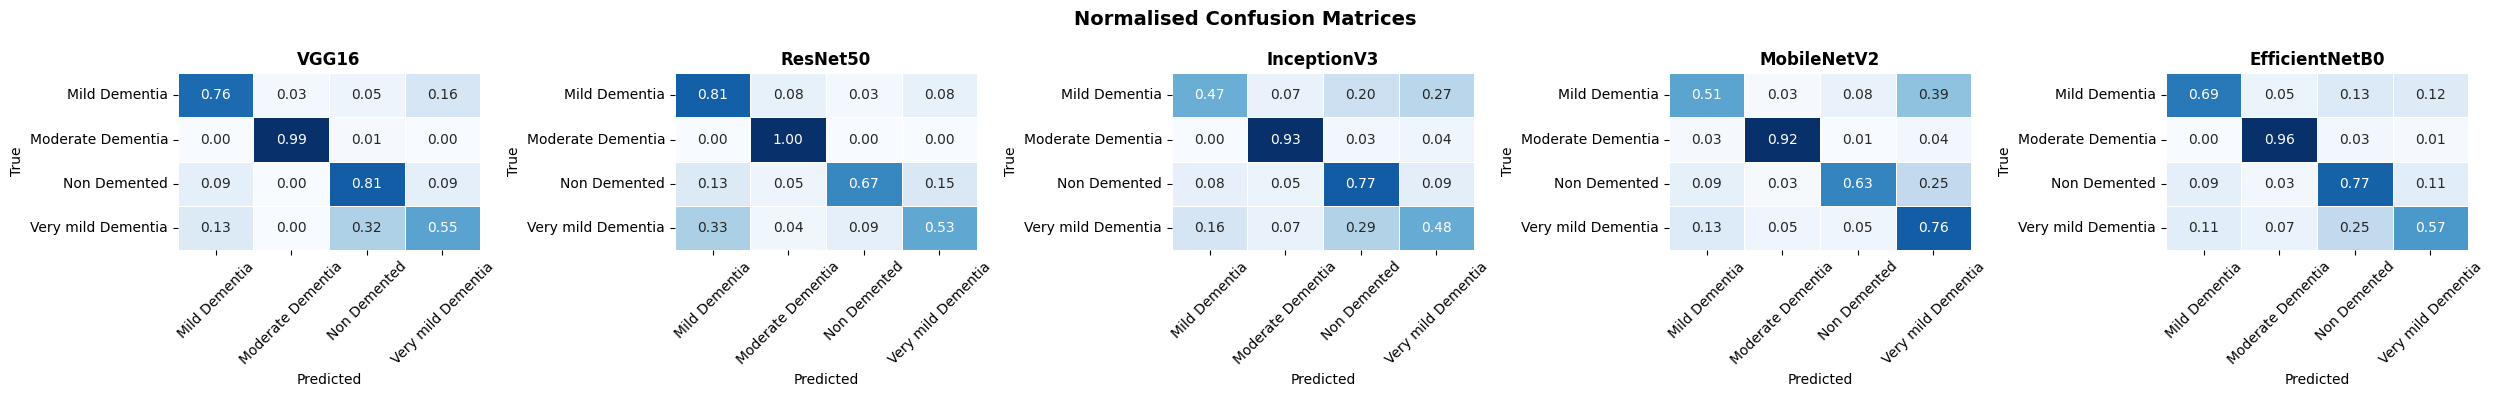

In [ ]:
# Confusion matrices — one per model
fig, axes = plt.subplots(1, len(ARCHITECTURES), figsize=(5*len(ARCHITECTURES), 4))
for ax, (arch_name, model) in zip(axes, MODELS.items()):
    _, _, tg = make_generators(arch_name)
    tg.reset()
    preds = np.argmax(model.predict(tg, verbose=0), axis=1)
    cm = confusion_matrix(tg.classes, preds)
    cm_n = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-8)
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, linewidths=0.5, cbar=False)
    ax.set_title(arch_name, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Normalised Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/confusion_matrices.png', dpi=120, bbox_inches='tight'); plt.show()

## 8 · Grad-CAM Visualisation

In [ ]:
def get_last_conv_layer_name(model):
    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D): return layer.name
        if hasattr(layer, 'layers'):
            for sub in reversed(layer.layers):
                if isinstance(sub, layers.Conv2D): return sub.name
    return None

def make_gradcam_heatmap(img_array, model, last_conv_name):
    # Build sub-model outputting the last conv feature map + final predictions
    try:
        conv_layer = model.get_layer(last_conv_name)
        grad_model = Model([model.inputs], [conv_layer.output, model.output])
    except ValueError:
        for l in model.layers:
            if hasattr(l, 'layers'):
                try:
                    _ = l.get_layer(last_conv_name)
                    conv_layer = l.get_layer(last_conv_name)
                    grad_model = Model([model.inputs], [conv_layer.output, model.output])
                    break
                except: pass

    with tf.GradientTape() as tape:
        img_tensor = tf.cast(img_array, tf.float32)
        conv_outputs, predictions = grad_model(img_tensor)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads   = tape.gradient(class_channel, conv_outputs)
    pooled  = tf.reduce_mean(grads, axis=(0,1,2))
    heatmap = conv_outputs[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), CLASSES[pred_index]

def overlay_gradcam(img_path, heatmap, preprocess_fn, alpha=0.4):
    img = cv2.imread(str(img_path))
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    h   = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    h   = np.uint8(255 * h)
    cmap = cv2.applyColorMap(h, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img, 1-alpha, cmap, alpha, 0)
    return cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

print('Grad-CAM helpers ready.')

Grad-CAM helpers ready.


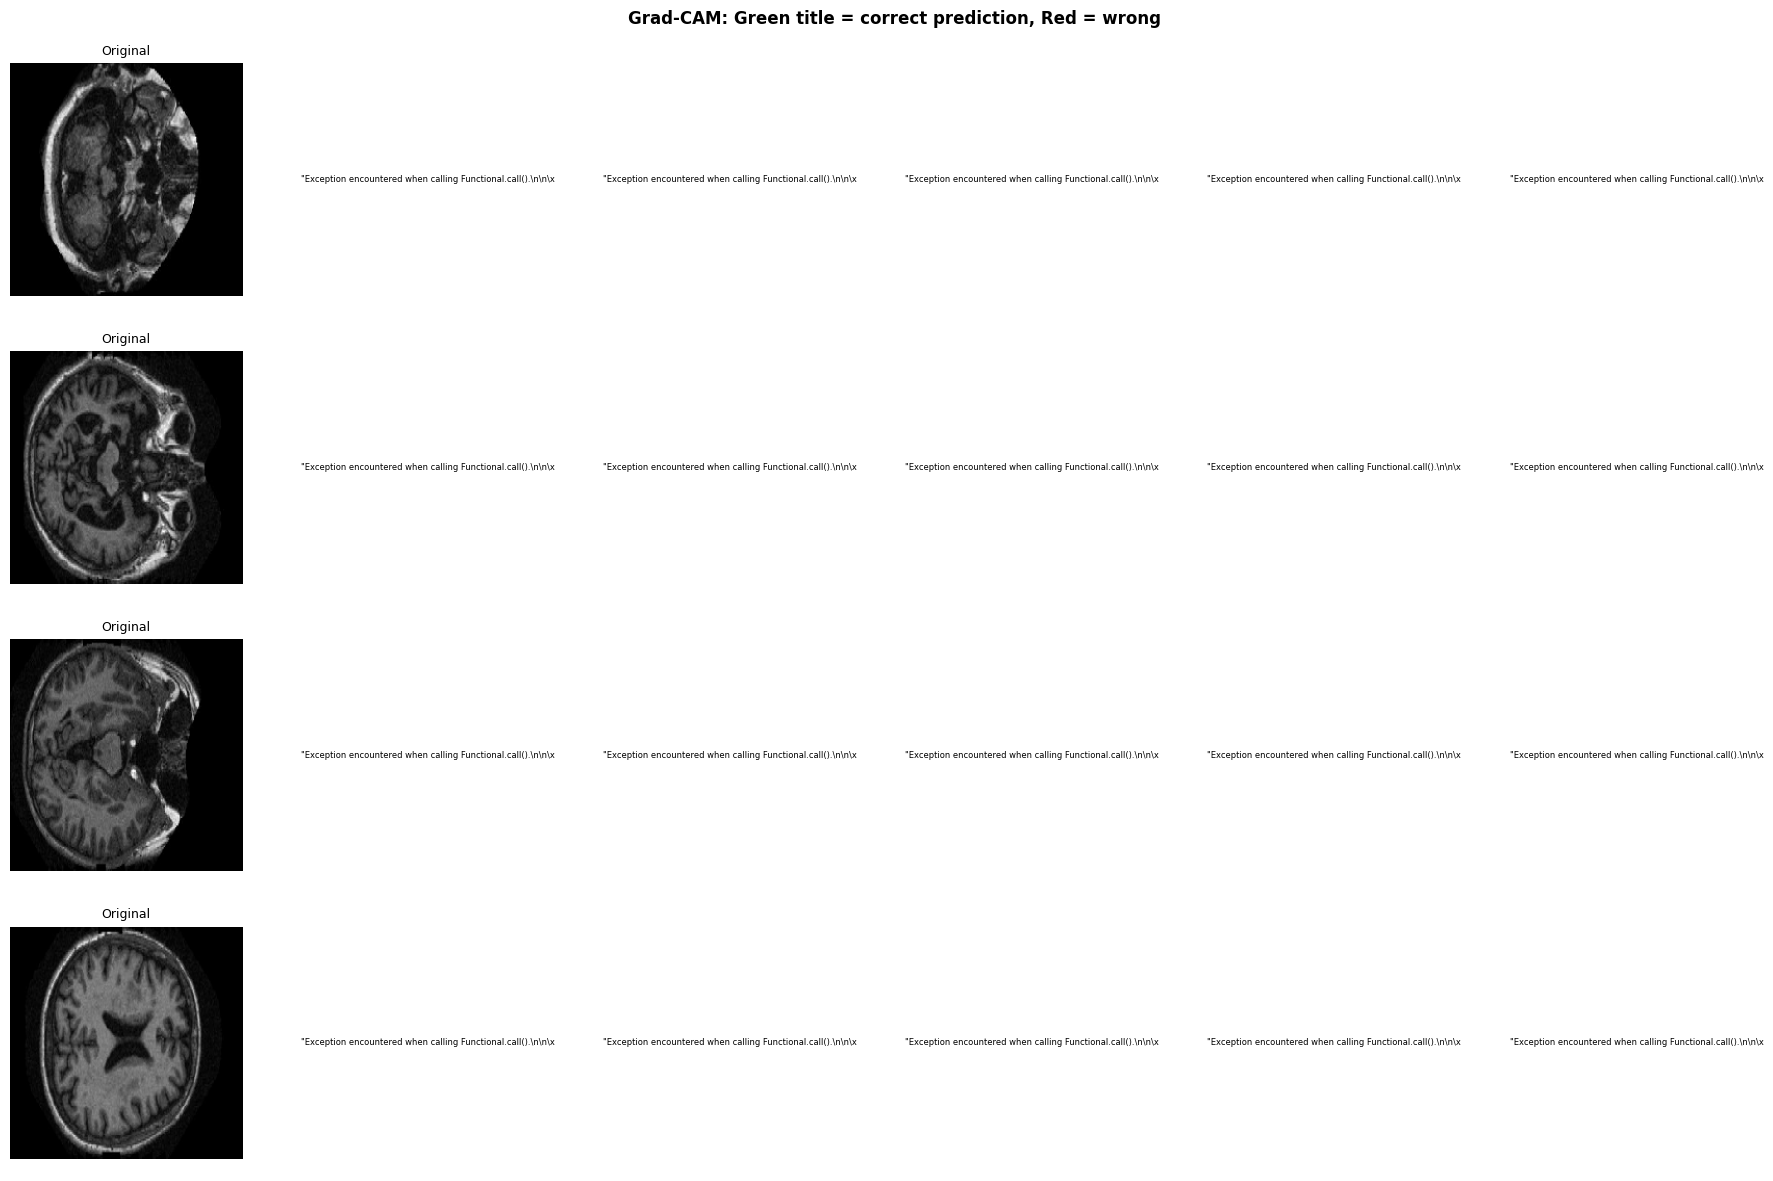

In [ ]:
test_root   = Path(SUBSET_ROOT) / 'test'
sample_imgs = {cls: list((test_root/cls).glob('*'))[0] for cls in CLASSES}

fig, axes = plt.subplots(
    len(CLASSES), len(ARCHITECTURES)+1,
    figsize=(3*(len(ARCHITECTURES)+1), 3*len(CLASSES))
)

for r, cls in enumerate(CLASSES):
    img_path = sample_imgs[cls]
    raw_img  = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_arr  = tf.keras.utils.img_to_array(raw_img)

    # Show original
    ax = axes[r, 0]
    ax.imshow(img_arr.astype('uint8'))
    ax.set_title('Original', fontsize=9)
    ax.set_ylabel(cls.replace('_',' '), fontweight='bold', fontsize=9)
    ax.axis('off')

    for c, (arch_name, model) in enumerate(MODELS.items()):
        ax = axes[r, c+1]
        try:
            preprocess_fn = PREPROCESS_FN[arch_name]
            img_preprocessed = preprocess_fn(np.expand_dims(img_arr.copy(), 0))
            conv_name = get_last_conv_layer_name(model)
            heatmap, pred_label = make_gradcam_heatmap(img_preprocessed, model, conv_name)
            overlay = overlay_gradcam(img_path, heatmap, preprocess_fn)
            ax.imshow(overlay)
            correct = (pred_label == cls)
            color   = 'green' if correct else 'red'
            ax.set_title(f'{arch_name}\nPred: {pred_label.replace("_"," ")}',
                         fontsize=7, color=color)
        except Exception as e:
            ax.text(0.5, 0.5, str(e)[:60], ha='center', va='center', fontsize=6, wrap=True)
        ax.axis('off')

plt.suptitle('Grad-CAM: Green title = correct prediction, Red = wrong', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/gradcam_all.png', dpi=120, bbox_inches='tight')
plt.show()

## 9 · Summary & Ensemble

In [ ]:
rows = []
for name, r in RESULTS.items():
    rows.append({
        'Architecture': name,
        'Test Acc':     f"{r['test_acc']:.4f}",
        'Test Loss':    f"{r['test_loss']:.4f}",
        'Time (min)':   f"{r['time_min']:.1f}",
        'Params (M)':   f"{r['params']/1e6:.1f}"
    })
df = pd.DataFrame(rows).sort_values('Test Acc', ascending=False).reset_index(drop=True)
print('\n📊 RESULTS SUMMARY')
print(df.to_string(index=False))
best = df.iloc[0]['Architecture']
print(f'\n🏆 Best model: {best}')


📊 RESULTS SUMMARY
  Architecture Test Acc Test Loss Time (min) Params (M)
         VGG16   0.7759    0.7806       10.2       15.1
      ResNet50   0.7525    0.8203        7.7       24.8
EfficientNetB0   0.7492    0.8567        7.7        4.8
   MobileNetV2   0.7023    0.9111        6.7        3.1
   InceptionV3   0.6622    0.9232        8.2       23.0

🏆 Best model: VGG16


In [ ]:
# ── Soft-voting ensemble of top-2 ─────────────────────────────────────────
top2 = df.head(2)['Architecture'].tolist()
print(f'Ensemble of: {top2}')

all_probs = []
for name in top2:
    _, _, tg = make_generators(name)
    tg.reset()
    probs = MODELS[name].predict(tg, verbose=0)
    all_probs.append(probs)

ens_probs = np.mean(all_probs, axis=0)
ens_preds = np.argmax(ens_probs, axis=1)

# Get true labels from the last test_gen
_, _, tg = make_generators(top2[0])
tg.reset()
_ = MODELS[top2[0]].predict(tg, verbose=0)  # Run to populate .classes
trues   = tg.classes
ens_acc = (ens_preds == trues).mean()

print(f'\nEnsemble Test Accuracy: {ens_acc:.4f}')
for n in top2: print(f'  {n}: {RESULTS[n]["test_acc"]:.4f}')
print(f'  Ensemble: {ens_acc:.4f}')

if ens_acc > max(RESULTS[n]['test_acc'] for n in top2):
    print('✅ Ensemble IMPROVES — merge is beneficial!')
else:
    print('⚠️  Best single model is sufficient, ensemble adds noise.')

print('\nDetailed report:')
print(classification_report(trues, ens_preds, target_names=CLASSES))

Ensemble of: ['VGG16', 'ResNet50']
Found 1391 images belonging to 4 classes.
Found 298 images belonging to 4 classes.
Found 299 images belonging to 4 classes.
Found 1391 images belonging to 4 classes.
Found 298 images belonging to 4 classes.
Found 299 images belonging to 4 classes.
Found 1391 images belonging to 4 classes.
Found 298 images belonging to 4 classes.
Found 299 images belonging to 4 classes.

Ensemble Test Accuracy: 0.7860
  VGG16: 0.7759
  ResNet50: 0.7525
  Ensemble: 0.7860
✅ Ensemble IMPROVES — merge is beneficial!

Detailed report:
                    precision    recall  f1-score   support

     Mild Dementia       0.70      0.85      0.77        75
 Moderate Dementia       0.95      1.00      0.97        74
      Non Demented       0.75      0.73      0.74        75
Very mild Dementia       0.75      0.56      0.64        75

          accuracy                           0.79       299
         macro avg       0.79      0.79      0.78       299
      weighted avg      

In [ ]:
# Save best model + download all
MODELS[best].save(f'/content/{best}_alzheimer_fixed.keras')
print(f'Saved: /content/{best}_alzheimer_fixed.keras')

from google.colab import files
for f in ['training_curves.png','model_comparison.png','confusion_matrices.png','gradcam_all.png']:
    p = f'/content/{f}'
    if os.path.exists(p): files.download(p)
files.download(f'/content/{best}_alzheimer_fixed.keras')

Saved: /content/VGG16_alzheimer_fixed.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 📝 Expected Results After Fix

| Architecture | Expected Acc | Speed | Notes |
|---|---|---|---|
| **EfficientNetB0** | 78–88% | Fast | Best accuracy, sensitive to LR |
| **MobileNetV2** | 75–85% | Fastest | Great for Colab free tier |
| **InceptionV3** | 72–82% | Medium | Multi-scale features help |
| **ResNet50** | 70–80% | Medium | Needs more epochs to converge |
| **VGG16** | 65–75% | Slowest | Heaviest model, decent baseline |

### If accuracy is still low:
1. Increase `MAX_PER_CLASS` to 800–1000
2. Increase `EPOCHS` to 30
3. Try `FINE_TUNE_AFTER = 10` (more frozen warmup)
4. Check that the dataset unpacked correctly — print a few images per class

### Merge strategy:
- Merge if top-2 models are architecturally different (e.g. EfficientNet + MobileNet)
- Skip merge if one model dominates by >5%
